In [74]:
from astropy import units as u
from astropy.constants import k_B, R, G, c
import spacehub_calc
from spacehub_calc import ensure_unit
import numpy as np
pi = np.pi
import subprocess
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import display, clear_output, HTML
import seaborn as sns
import pandas as pd
from scipy.interpolate import PchipInterpolator

uyr = u.yr/(2*np.pi)

v0 = 100 * u.km/u.s
rho =  1e-12 * u.kg/(u.cm*u.cm*u.cm)
R = 12*u.km
M = 0.4 * u.Msun
cs = 100 * u.km/u.s;

In [75]:
def interp_intercept(x, y, intercept=0, npoints=1e3, returnCurves=False):
    f = PchipInterpolator(x, y)
    x_fine = np.linspace(min(x), max(x), int(npoints))
    y_fine = f(x_fine)
    offset = y_fine - intercept
    idx_list = np.argwhere(np.diff(np.sign(offset))).flatten()
    if len(idx_list) == 0:
        print(f"No crossing found")
        return [0,0]
    
    idx = idx_list[0]
    point = [x_fine[idx], y_fine[idx]]
    if returnCurves:
        return point, x_fine, y_fine
    else:
        return point

In [76]:


time = [0*u.yr]
velocity = [v0]
machs = [(v0/cs).si.value]

def IBH(mach):
    return 1/(1+mach**2)
while velocity[-1].value > 1e-6:
    v = velocity[-1]
    t = time[-1]
    mach = (v/cs).si.value
    machs.append(mach)
    dt = 0.01*u.yr
    Fm = (IBH(mach) * (rho*4*np.pi*(G*M)**2) ) / cs**2 /M
    dv = dt*Fm
    time.append(t+dt)
    velocity.append(v-dv)
    #print(v-dv)

In [77]:
if True:


    time_super = [0*u.yr]
    velocity_super = [v0]
    machs_super = [(v0/cs).si.value]


    while velocity_super[-1].value > 1e-6:
        v = velocity_super[-1]
        t = time_super[-1]
        mach = (v/cs).si.value
        machs_super.append(mach)
        dt = 0.01*u.yr
        Fm = (rho*4*np.pi*M*(G)**2) / (v**2)
        dv = dt*Fm
        time_super.append(t+dt)
        velocity_super.append(v-dv)
        print(v-dv)

99.99859495193847 km / s
99.99718986439291 km / s
99.99578473736054 km / s
99.99437957083859 km / s
99.99297436482429 km / s
99.99156911931486 km / s
99.99016383430752 km / s
99.9887585097995 km / s
99.98735314578802 km / s
99.98594774227031 km / s
99.98454229924359 km / s
99.98313681670507 km / s
99.981731294652 km / s
99.98032573308157 km / s
99.97892013199103 km / s
99.97751449137759 km / s
99.97610881123848 km / s
99.97470309157092 km / s
99.97329733237211 km / s
99.9718915336393 km / s
99.97048569536969 km / s
99.96907981756051 km / s
99.96767390020898 km / s
99.96626794331232 km / s
99.96486194686774 km / s
99.96345591087247 km / s
99.96204983532371 km / s
99.9606437202187 km / s
99.95923756555464 km / s
99.95783137132877 km / s
99.95642513753829 km / s
99.95501886418042 km / s
99.95361255125238 km / s
99.95220619875138 km / s
99.95079980667465 km / s
99.94939337501938 km / s
99.9479869037828 km / s
99.94658039296213 km / s
99.9451738425546 km / s
99.9437672525574 km / s
99.94236

In [78]:
dv.si

<Quantity 25216.45992365 m / s>

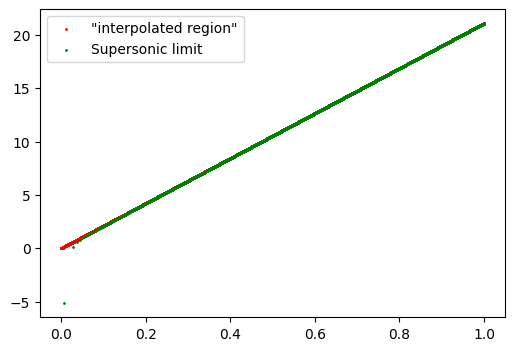

In [79]:
fig, ax = plt.subplots(figsize=(6,4))


ax.scatter(machs, [v.to(u.AU/u.yr).value for v in velocity], s=1, label="\"interpolated region\"", color="red")
ax.scatter(machs_super, [v.to(u.AU/u.yr).value for v in velocity_super], s=1, label="Supersonic limit", color="green")
ax.legend()


(0.0, 1.5)

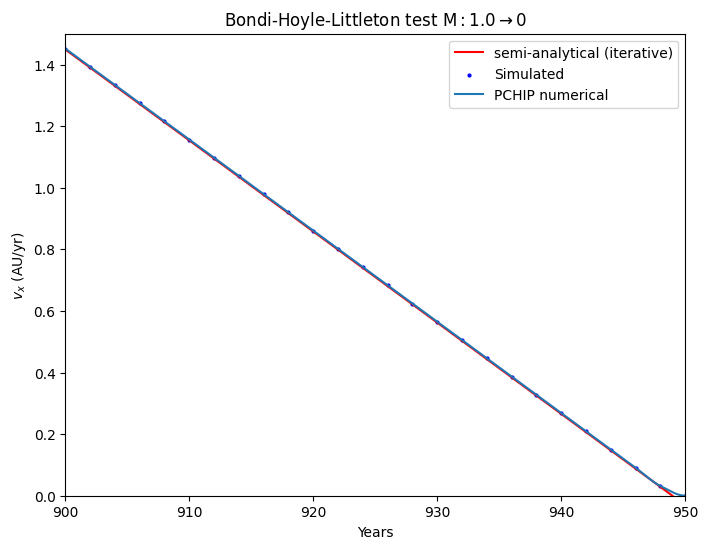

In [83]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot([t.to(u.yr).value for t in time], [v.to(u.AU/u.yr).value for v in velocity],  label="semi-analytical (iterative)", color="red")
dfi = pd.read_csv("testbhldrag-mildMachRegime.csv")
df = dfi[dfi["id"]==0]
t_real = df["time"] / (2*np.pi)
vdata_real = df["vx"] * (2*np.pi)
ax.scatter(t_real, vdata_real, color="blue", s=4, label="Simulated")
point, xs, ys = interp_intercept(t_real, vdata_real, intercept=1e-4, npoints=1e5, returnCurves=True)
ax.plot(xs,ys, label="PCHIP numerical")
ax.set_xlabel("Years")
ax.set_ylabel(r"$v_x$ (AU/yr)")
ax.legend()
ax.set_xlim(900,950)
ax.set_title(r"Bondi-Hoyle-Littleton test $\mathrm{M}:1.0\rightarrow0$")
ax.set_ylim(0,1.5)

In [81]:
def stoptime(m, cs, rho, vi, vf=0, unit=u.yr):
    
    coeff = (cs**3) / (4*pi*(G**2)*m*rho)

    Mi = vi/cs
    Mf = vf/cs if vf > 0 else 0

    integral_i = (Mi**3)/3 + Mi
    integral_f = ( (Mf**3)/3 + Mf ) if vf > 0 else 0

    tau = -coeff * (integral_f - integral_i)
    return tau.to(unit)


    


    

tstop_analytical = stoptime(m = 0.4 * u.Msun, 
         cs = 100 * u.km/u.s, 
         rho =  1e-12 * u.kg/(u.cm*u.cm*u.cm), 
         vi=100 * u.km/u.s )


tstop_analytical

<Quantity 948.95923481 yr>

In [82]:
point, xs, ys = interp_intercept(t_real, vdata_real, intercept=0.0001, npoints=1e5, returnCurves=True)
tstop_numerical = point[0] * u.yr
tstop_numerical

<Quantity 949.91949919 yr>

Note the $1\mathrm{yr}$ difference is because I set the stop time in the .cpp file about 50 years after the stopping time, so the interpolation is picking up a few extra 0 values